# Zero Order Hold: planet to planet low thrust transfer

In this tutorial we demonstrate the use of the `zoh_pl2pl` class to find a low-thrust trajectory connecting two moving planets using the **Zero-Order Hold (ZOH)** direct method with free departure and arrival velocities.

## Key Features

The `zoh_pl2pl` class offers several features that make it a powerful tool for low-thrust trajectory optimization:

1. **Free departure and arrival velocities** - The spacecraft can depart and arrive with excess velocity relative to the planets
2. **Non-dimensional formulation** - Works internally with non-dimensional units for better numerical conditioning
3. **Taylor-adaptive integration** - Uses heyoka as Taylor propagator for accurate trajectory propagation
4. **Analytical gradients** - Optional analytical gradient computation for faster optimization
5. **Flexible time encoding** - Supports both `uniform` and `softmax` time grid encodings

## Decision Vector

The decision vector for this class is:

$$
\mathbf{x} = [t_0, m_f, v^{\infty}_{\text{dep}}, \hat{i}_{\text{dep},x}, \hat{i}_{\text{dep},y}, \hat{i}_{\text{dep},z}, v^{\infty}_{\text{arr}}, \hat{i}_{\text{arr},x}, \hat{i}_{\text{arr},y}, \hat{i}_{\text{arr},z}, \text{controls}, T_{\text{tof}}] (+ [\mathbf{w}] \text{ for softmax})
$$

Where:
- $t_0$ is the departure epoch (MJD2000, in days)
- $m_f$ is the final spacecraft mass (non-dimensional)
- $v^{\infty}_{\text{dep/arr}}$ are the magnitudes of departure/arrival excess velocities (non-dimensional)
- $\hat{i}_{\text{dep/arr}}$ are unit direction vectors for the excess velocities
- controls = $[T, \hat{i}_x, \hat{i}_y, \hat{i}_z] \times n_{\text{seg}}$ where $T$ is thrust magnitude and $\hat{i}$ is thrust direction
- $T_{\text{tof}}$ is the time of flight (non-dimensional)
- $\mathbf{w}$ are softmax weights (only for softmax encoding)

:::{note}
This notebook can use the commercial solver SNOPT 7 or the open-source IPOPT solver. Both are demonstrated below.
:::

## Basic Imports

In [1]:
import pykep as pk
import numpy as np
import time
import pygmo as pg
try:
    import pygmo_plugins_nonfree as ppnf
    has_snopt = True
except:
    has_snopt = False
    print("SNOPT not available, will use IPOPT instead")

from matplotlib import pyplot as plt

## Problem Definition

We define the problem parameters including planets, spacecraft characteristics, and non-dimensional scaling factors.

In [2]:
# Problem data
mu = pk.MU_SUN
max_thrust = 0.6
isp = 3000
veff = isp * pk.G0
# Initial mass
ms = 1500.0
# Number of segments
nseg = 30

# Non dimensional units
L = pk.AU
MU = mu  # (central body mu must be 1 in these units as a requirement of the ZOH integrator used)
TIME = np.sqrt(L**3 / MU)
V = L / TIME
ACC = V / TIME
MASS = ms
F = MASS * ACC
ms_nd = ms / MASS

# Source and destination planets
earth = pk.planet_to_keplerian(
    pk.planet(pk.udpla.jpl_lp(body="EARTH")), 
    when=pk.epoch(5000),
)
mars = pk.planet_to_keplerian(
    pk.planet(pk.udpla.jpl_lp(body="MARS")), 
    when=pk.epoch(5000),
)

# Low tolerances result in higher speed (the needed tolerance depends on the orbital regime)
tol = 1e-10
tol_var = 1e-6

# We instantiate ZOH Taylor integrators for Keplerian dynamics.
ta = pk.ta.get_zoh_kep(tol)
ta_var = pk.ta.get_zoh_kep_var(tol_var)

# We set the Taylor integrator parameters
veff_nd = veff / V

# Creating Taylor-Adaptive Integrators
# The ZOH method requires Taylor-adaptive integrators for high-precision trajectory propagation. We create two integrators:
# 1. Nominal dynamics integrator (for fitness evaluation)
# 2. Variational dynamics integrator (for gradient computation)
ta.pars[4] = 1.0 / veff_nd
ta_var.pars[4] = 1.0 / veff_nd
print(f"Nominal integrator state dimension: {len(ta.state)}")
print(f"Variational integrator state dimension: {len(ta_var.state)}")

Nominal integrator state dimension: 7
Variational integrator state dimension: 84


In [3]:
udp_uniform = pk.trajopt.zoh_pl2pl(
    pls=earth,
    plf=mars,
    ms=ms_nd,
    nseg=nseg,
    cut=0.6,
    t0_bounds=[7360, 8300.0],
    tof_bounds=[100.*pk.DAY2SEC/TIME, 350.*pk.DAY2SEC/TIME],
    mf_bounds=[2/3,1.],
    vinf_dep_bounds = [0., 0.],
    vinf_arr_bounds = [0., 0.],
    tas = (ta,None),
    max_thrust=max_thrust/F,
    # w_bounds_softmax=[-1., 1.],
    time_encoding='uniform',
)

udp_g_uniform = pk.trajopt.zoh_pl2pl(
    pls=earth,
    plf=mars,
    ms=ms_nd,
    nseg=nseg,
    cut=0.6,
    t0_bounds=[7360, 8300.0],
    tof_bounds=[100.*pk.DAY2SEC/TIME, 350.*pk.DAY2SEC/TIME],
    mf_bounds=[2/3,1.],
    vinf_dep_bounds = [0., 0.],
    vinf_arr_bounds = [0., 0.],
    tas = (ta,ta_var),
    max_thrust=max_thrust/F,
    # w_bounds_softmax=[-1., 1.],
    time_encoding='uniform',
    )

print("UDP instances created successfully")
print(f"With gradient: {udp_g_uniform.has_gradient()}")
print(f"Without gradient: {udp_uniform.has_gradient()}")

UDP instances created successfully
With gradient: True
Without gradient: False


## Part 1: Gradient vs No-Gradient Comparison

We first compare the performance of the UDP with and without analytical gradients. Both use uniform time encoding.

### Gradient Performance Analysis

Let's compare the performance of analytical gradients versus numerical gradients. 
The analytical gradients use variational equations integrated alongside the dynamics, providing exact derivatives.

In [4]:
# Create a problem and population to test gradient
prob_g = pg.problem(udp_g_uniform)
pop_g = pg.population(prob_g, 1)
x_test = pop_g.champion_x

print("\n=== Gradient Performance Comparison ===")
print(f"\nDecision vector dimension: {len(x_test)}")
print(f"Fitness dimension: {len(prob_g.fitness(x_test))}")

print("\nAnalytical gradient (from variational equations + chain rule):")
%timeit udp_g_uniform.gradient(x_test)

print("\nNumerical gradient (simple finite difference):")
%timeit pg.estimate_gradient(udp_g_uniform.fitness, x_test)

print("\n✓ The analytical gradient is significantly faster!")


=== Gradient Performance Comparison ===

Decision vector dimension: 131
Fitness dimension: 40

Analytical gradient (from variational equations + chain rule):
696 μs ± 24.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

Numerical gradient (simple finite difference):
26.6 ms ± 398 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

✓ The analytical gradient is significantly faster!


### Solving with and without Gradients

Now we solve the optimization problem using both approaches to compare convergence.

In [5]:
# Setup optimization algorithm
if has_snopt:
    # Use SNOPT if available
    library_snopt72 = "/Users/dario.izzo/opt/libsnopt7_c.dylib"
    uda = ppnf.snopt7(library=library_snopt72, minor_version=2, screen_output=False)
    uda.set_integer_option("Major iterations limit", 1000)
    uda.set_integer_option("Iterations limit", 10000)
    uda.set_numeric_option("Major optimality tolerance", 1e-3)
    uda.set_numeric_option("Major feasibility tolerance", 1e-9)
    algo_name = "SNOPT7"
else:
    # Use IPOPT as fallback
    uda = pg.ipopt()
    uda.set_numeric_option("tol", 1e-8)
    uda.set_numeric_option("constr_viol_tol", 1e-8)
    uda.set_integer_option("max_iter", 2000)
    algo_name = "IPOPT"

algo = pg.algorithm(uda)
print(f"Using {algo_name} optimizer")

Using SNOPT7 optimizer


#### Optimization with Gradients

In [6]:
# Solve with gradients
prob_g_uniform = pg.problem(udp_g_uniform)
prob_g_uniform.c_tol = 1e-6

print("\n=== Optimization WITH Gradients (Uniform) ===")

masses = []
xs=[]
for i in range(10):
    pop_g = pg.population(prob_g_uniform, 1)
    pop_g = algo.evolve(pop_g)
    if(prob_g_uniform.feasibility_f(pop_g.champion_f)):
        print(".", end="")
        masses.append(pop_g.champion_x[1])
        xs.append(pop_g.champion_x)
    else:
        print("x", end ="")
print("\nBest mass is: ", np.max(masses)*MASS)
print("Worst mass is: ", np.min(masses)*MASS)
best_idx = np.argmax(masses)


=== Optimization WITH Gradients (Uniform) ===
x.........
Best mass is:  1233.78782465
Worst mass is:  1209.72980171


#### Optimization without Gradients

In [7]:
prob_uniform = pg.problem(udp_uniform)
prob_uniform.c_tol = 1e-6
print("\n=== Optimization WITHOUT Gradients (Uniform) ===")
masses_no_grad = []
for i in range(10):
    pop = pg.population(prob_uniform, 1)
    pop = algo.evolve(pop)
    if(prob_uniform.feasibility_f(pop.champion_f)):
        print(".", end="")
        masses_no_grad.append(pop.champion_x[1])
    else:
        print("x", end ="")
print("\nBest mass is: ", np.max(masses_no_grad)*MASS)
print("Worst mass is: ", np.min(masses_no_grad)*MASS)


=== Optimization WITHOUT Gradients (Uniform) ===
..x.x.....
Best mass is:  1233.19966226
Worst mass is:  1216.47963104


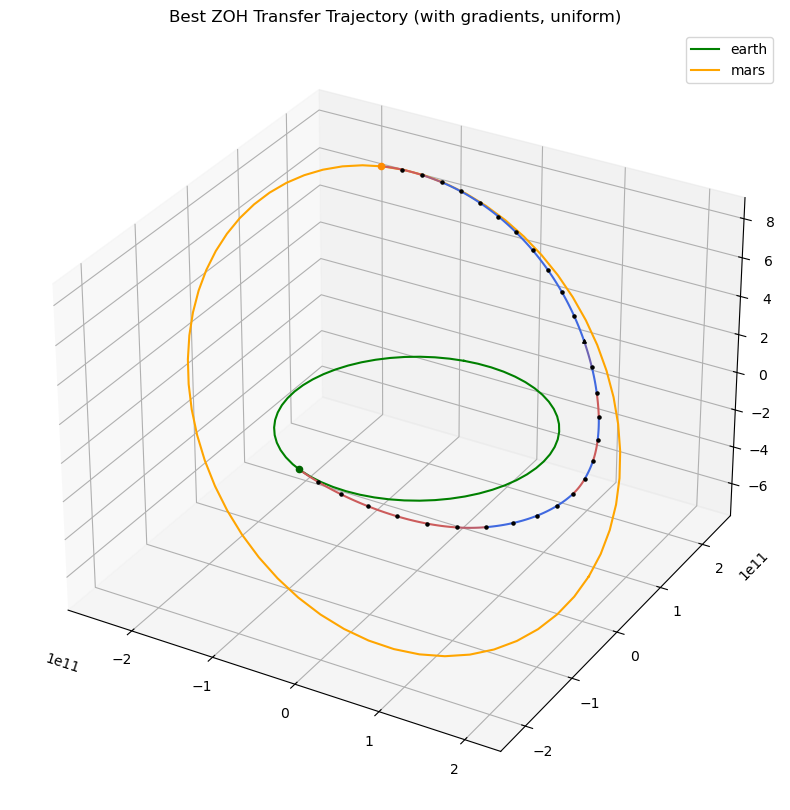

In [8]:
if len(xs) > 0:
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')  
    t0 = udp_g_uniform.compute_t0(xs[best_idx])
    ax=pk.plot.add_planet_orbit(ax=ax, pla=earth, label='earth', units=1., color='green')
    ax=pk.plot.add_planet_orbit(ax=ax, pla=mars, label='mars', units=1., color='orange')
    ax = udp_g_uniform.plot(xs[best_idx], ax=ax, N=20, c='k', s=5)
    ax=pk.plot.add_planet(ax=ax, when=t0, pla=earth, units=1., color='darkgreen', s=20)
    ax=pk.plot.add_planet(ax=ax, when=t0+xs[best_idx][10+4*udp_g_uniform.nseg]*udp_g_uniform.TIME/pk.DAY2SEC, pla=mars, units=1., color='darkorange', s=20)
    ax.set_title("Best ZOH Transfer Trajectory (with gradients, uniform)")
    ax.legend()    

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

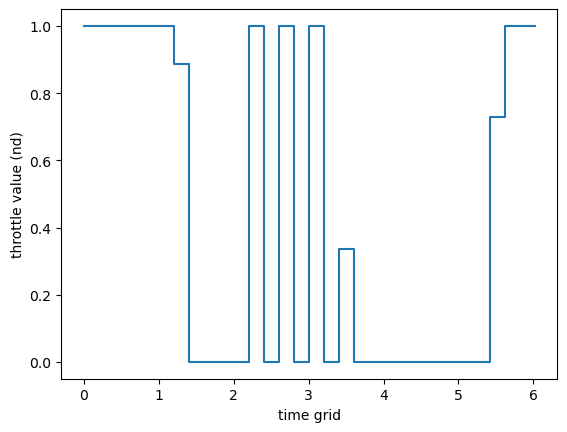

In [14]:
udp_g_uniform.plot_throttle(xs[best_idx])

## Part 2: Time Encoding Comparison (Uniform vs Softmax)

Now we compare the two time encoding methods: `uniform` and `softmax`.

### Time Encoding Explanation

**Uniform Encoding:** Time grid nodes are evenly spaced from 0 to TOF:
$$t_i = \frac{i \cdot T_{\text{tof}}}{n_{\text{seg}}}, \quad i = 0, 1, ..., n_{\text{seg}}$$

**Softmax Encoding:** Time grid nodes are determined by learnable weights $\mathbf{w}$:
$$\Delta t_i = T_{\text{tof}} \cdot \text{softmax}(\mathbf{w})_i, \quad t_i = \sum_{j=0}^{i-1} \Delta t_j$$

The softmax encoding adds $n_{\text{seg}}$ additional decision variables but allows the optimizer to adaptively distribute time where it's most needed.
For a better discussion on the softmax encoding see also the tutorial: `udp_zoh_point2point.ipynb`.

### Create UDP with Softmax Encoding

In [9]:
udp_g_softmax = pk.trajopt.zoh_pl2pl(
    pls=earth,
    plf=mars,
    ms=ms_nd,
    nseg=nseg,
    cut=0.6,
    t0_bounds=[7360, 8300.0],
    tof_bounds=[100.*pk.DAY2SEC/TIME, 350.*pk.DAY2SEC/TIME],
    mf_bounds=[2/3,1.],
    vinf_dep_bounds = [0., 0.],
    vinf_arr_bounds = [0., 0.],
    tas = (ta,ta_var),
    max_thrust=max_thrust/F,
    w_bounds_softmax=[-1., 1.],
    time_encoding='softmax',
    )

print("UDP with softmax encoding created successfully")
print(f"Decision vector size:")
print(f"With softmax: {len(udp_g_softmax.get_bounds()[0])} (includes softmax weights)")
print(f"Without softmax: {len(udp_g_uniform.get_bounds()[0])}")

UDP with softmax encoding created successfully
Decision vector size:
With softmax: 161 (includes softmax weights)
Without softmax: 131


### Solve with Softmax Encoding

In [10]:
#solve with gradients:
prob_g_softmax = pg.problem(udp_g_softmax)
prob_g_softmax.c_tol = 1e-6
print("\n=== Optimization WITH Gradients (Softmax) ===")
masses_softmax = []
xs_softmax = []

for i in range(10):
    pop_g_sm = pg.population(prob_g_softmax, 1)
    pop_g_sm = algo.evolve(pop_g_sm)
    if(prob_g_softmax.feasibility_f(pop_g_sm.champion_f)):
        print(".", end="")
        masses_softmax.append(pop_g_sm.champion_x[1])
        xs_softmax.append(pop_g_sm.champion_x)
    else:
        print("x", end ="")
print("\nBest mass is: ", np.max(masses_softmax)*MASS)
print("Worst mass is: ", np.min(masses_softmax)*MASS)
best_idx_sm = np.argmax(masses_softmax)


=== Optimization WITH Gradients (Softmax) ===
x.....xx.x
Best mass is:  1233.65545015
Worst mass is:  1215.44188073


### Display Best Solution with Softmax

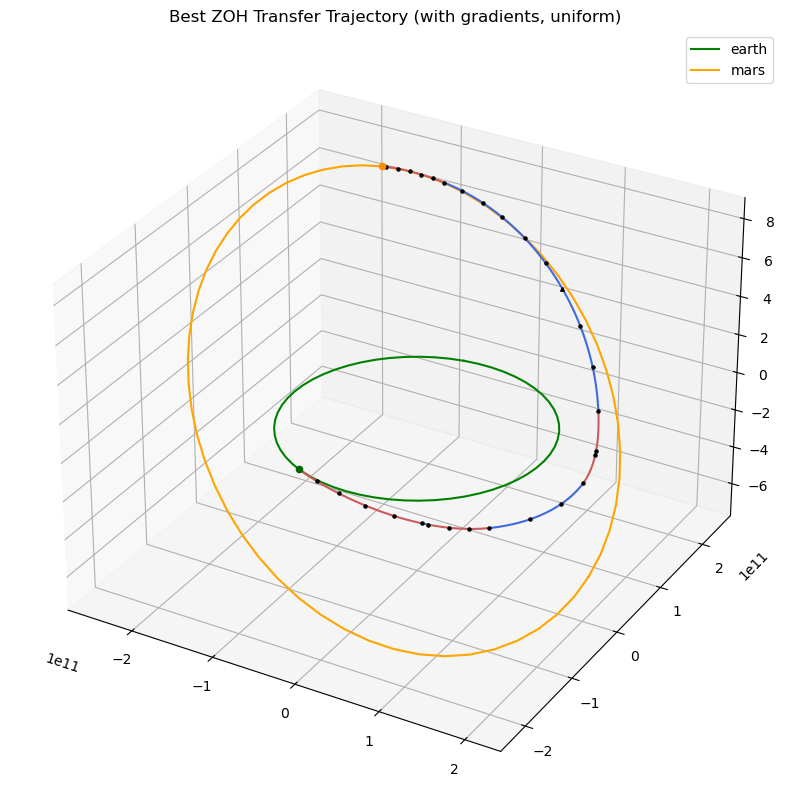

In [11]:
if len(xs) > 0:
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')  
    t0 = udp_g_softmax.compute_t0(xs_softmax[best_idx_sm])
    ax=pk.plot.add_planet_orbit(ax=ax, pla=earth, label='earth', units=1., color='green')
    ax=pk.plot.add_planet_orbit(ax=ax, pla=mars, label='mars', units=1., color='orange')
    ax = udp_g_softmax.plot(xs_softmax[best_idx_sm], ax=ax, N=20, c='k', s=5)
    ax=pk.plot.add_planet(ax=ax, when=t0, pla=earth, units=1., color='darkgreen', s=20)
    ax=pk.plot.add_planet(ax=ax, when=t0+xs_softmax[best_idx_sm][10+4*udp_g_softmax.nseg]*udp_g_softmax.TIME/pk.DAY2SEC, pla=mars, units=1., color='darkorange', s=20)
    ax.set_title("Best ZOH Transfer Trajectory (with gradients, uniform)")
    ax.legend()    

In [12]:
udp_g_softmax.pretty(xs_softmax[best_idx_sm])


Low-thrust ZOH transfer (free velocities, non-dimensional formulation)
Departure: earth(jpl_lp)(K)
Arrival: mars(jpl_lp)(K)

Launch epoch: 7452.11748 MJD2000, a.k.a. 2020-05-27T02:49:10.229252
Arrival epoch: 7802.11748 MJD2000, a.k.a. 2021-05-12T02:49:10.229252
Time of flight: 6.02073 (nd), 350.00000 days

Departure excess velocity:
  Magnitude: 0.000000 (nd), 0.000000 km/s
  Vector (nd): [0.000000, -0.000000, 0.000000]
  Vector (km/s): [0.000000, -0.000000, 0.000000]
  Direction: [0.738962, -0.026113, 0.673240], norm: 1.000000

Arrival excess velocity:
  Magnitude: 0.000000 (nd), 0.000000 km/s
  Vector (nd): [-0.000000, 0.000000, -0.000000]
  Vector (km/s): [-0.000000, 0.000000, -0.000000]
  Direction: [-0.728527, 0.489609, -0.479094], norm: 1.000000

Final mass: 0.822437 (nd)

Scaling factors: L=149.598 Gm, V=29.785 km/s, TIME=58.132 days

Details on the ZOH leg:


<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

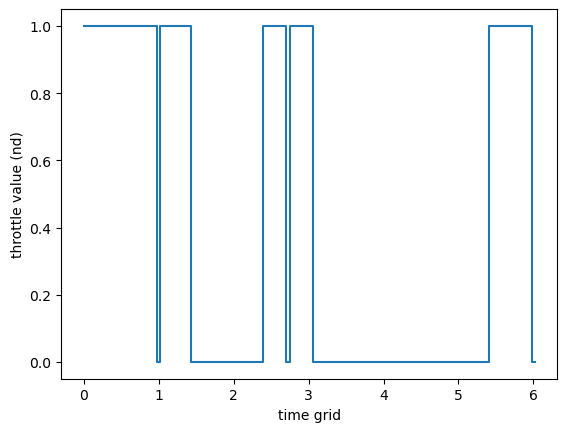

In [13]:
udp_g_softmax.plot_throttle(xs_softmax[best_idx_sm])